# Ni detector-image integration and Rietveld refinement

This notebook processes **Ni.tiff** using the supplied **_calibration.poni** and **_mask.edf**, matches **Ni.cif**, and performs a **structure-based Rietveld refinement** with easyXRD and GSAS-II. Instrument parameters are imported from **_instrument_parameters.gpx**. All input files are preserved.

Workflow adapted to the installed API from Mehmet Topsakal's [basic](https://github.com/MehmetTopsakal/easyXRD_examples/blob/main/01_basic.ipynb) and [intermediate](https://github.com/MehmetTopsakal/easyXRD_examples/blob/main/02_intermediate.ipynb) examples (local example repository commit `97dec4ef8260006ebe8a00b78da2bbf55d9cd5ff`). In particular, easyXRD normally enables Le Bail extraction; here it is explicitly disabled **before any refinement**.

Run all cells using `/home/mt/mpixi/.pixi/envs/default/bin/python` as the Jupyter kernel. Outputs are written to `Ni_results/` alongside this notebook. No downloads or API keys are needed. Executed on 2026-10-06.

In [1]:
import os, sys, json, hashlib, copy, shutil, importlib.metadata as metadata
from pathlib import Path
BASE = Path.cwd().resolve()
required = ['Ni.tiff', '_calibration.poni', '_mask.edf', 'Ni.cif', '_instrument_parameters.gpx']
assert all((BASE / f).is_file() for f in required), 'Run from the notebook directory containing the five input files.'
OUT = BASE / 'Ni_results'
OUT.mkdir(exist_ok=True)
os.environ['EASYXRD_SCRATCH'] = str(OUT / 'gsas_work')
os.environ.setdefault('NUMBA_CACHE_DIR', str(OUT / '.numba_cache'))
os.environ.setdefault('MPLCONFIGDIR', str(OUT / '.mpl_cache'))
os.environ.setdefault('OMP_NUM_THREADS', '4')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fabio, pyFAI
from easyxrd import exrd
from GSASII import GSASIIscriptable as G2sc
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from scipy.signal import find_peaks
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'figure.constrained_layout.use': True, 'font.size': 10})
versions = {'python': sys.version, 'executable': sys.executable}
for package in ['easyxrd', 'pyFAI', 'fabio', 'numpy', 'scipy', 'pymatgen', 'GSAS-II']:
    try: versions[package] = metadata.version(package)
    except metadata.PackageNotFoundError: versions[package] = 'see module location'
versions['GSASII_module'] = G2sc.__file__
input_hashes = {f: hashlib.sha256((BASE / f).read_bytes()).hexdigest() for f in required}
print(json.dumps(versions, indent=2))

{
  "python": "3.14.7 | packaged by conda-forge | (main, Sep  2 2026, 21:08:32) [GCC 15.3.0]",
  "executable": "/home/mt/mpixi/.pixi/envs/default/bin/python",
  "easyxrd": "2026.9.20",
  "pyFAI": "2026.5.0",
  "fabio": "2026.6.0",
  "numpy": "2.5.3",
  "scipy": "1.18.1",
  "pymatgen": "2026.9.24",
  "GSAS-II": "2.0.0",
  "GSASII_module": "/home/mt/mpixi/.pixi/envs/default/lib/python3.14/site-packages/GSASII/GSASIIscriptable.py"
}


## 1. Inspect the detector image, mask, calibration, and instrument reference

A nonzero mask value excludes a pixel. Nonfinite image pixels are also excluded. Negative finite TIFF values are retained: this is a corrected floating-point image, so negative values are not automatically detector defects. No additional dark, flat-field, median-filter, or polarization correction is invented. pyFAI's solid-angle correction is enabled. The GSAS-II polarization setting is imported unchanged.

Image: (3888, 3072); masked: 54,514/11,943,936 (0.456%)
Wavelength: 0.179900 Å; detector distance: 0.599497 m
# Nota: C-Order, 1 refers to the Y axis, 2 to the X axis
# Calibration done on Tue Sep 22 13:05:47 2026
poni_version: 2.1
Detector: Dexela2923
Detector_config: {"pixel1": 7.5e-05, "pixel2": 7.5e-05, "orientation": 3}
Distance: 0.5994971710951388
Poni1: 0.14065698666183532
Poni2: 0.09934596997307191
Rot1: -0.02386657077923864
Rot2: 0.007321294812142471
Rot3: 0.0
Wavelength: 1.799e-11
# Calibrant: Ni
# Image: fabio:///home/mt/repos/agent-work/assignments/Ni/20260731-131854_81DFC0_count_Ni-75-150_moving.tiff



,parameter,reference_value
0,Type,PXC
1,Bank,1.0
2,Lam,0.1799
3,Polariz.,0.0
4,Azimuth,0.0
5,Zero,0.0
6,U,-29.429568
7,V,13.791336
8,W,0.870891
9,X,0.07517


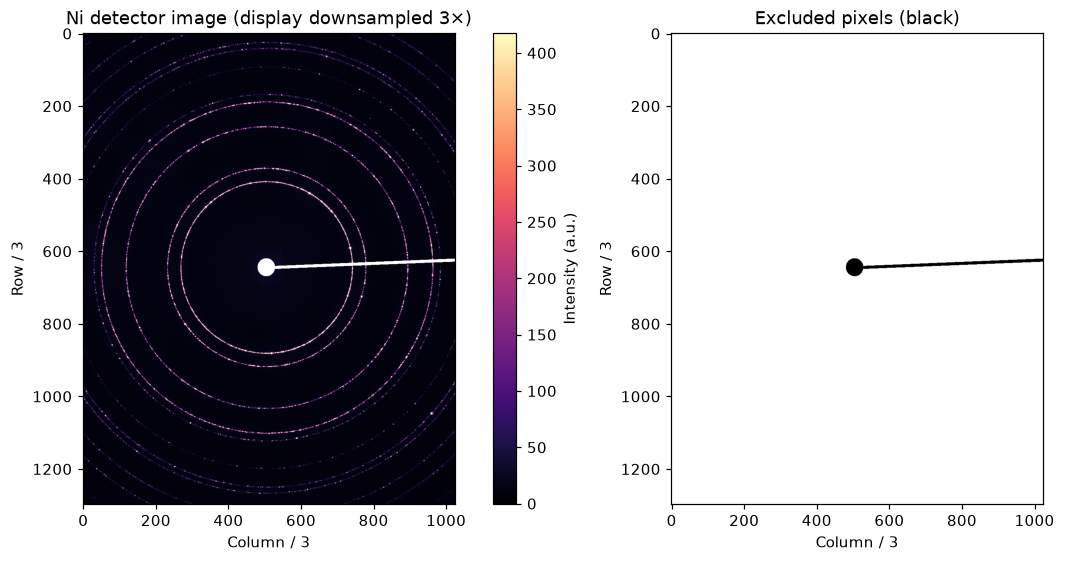

In [2]:
image = fabio.open(str(BASE / 'Ni.tiff')).data.astype(np.float32)
provided_mask = fabio.open(str(BASE / '_mask.edf')).data != 0
assert image.shape == provided_mask.shape
mask = provided_mask | ~np.isfinite(image)
ai = pyFAI.load(str(BASE / '_calibration.poni'))
wavelength = ai.wavelength * 1e10
reference = G2sc.G2Project(gpxfile=str(BASE / '_instrument_parameters.gpx'))
assert len(reference.histograms()) == 1, 'Select the appropriate instrument histogram explicitly.'
reference_hist = reference.histograms()[0]
reference_inst = copy.deepcopy(reference_hist.data['Instrument Parameters'][0])
assert np.isclose(reference_inst['Lam'][1], wavelength, atol=1e-6)
print(f'Image: {image.shape}; masked: {mask.sum():,}/{mask.size:,} ({100*mask.mean():.3f}%)')
print(f'Wavelength: {wavelength:.6f} Å; detector distance: {ai.dist:.6f} m')
print((BASE / '_calibration.poni').read_text())
display(pd.DataFrame([{'parameter': k, 'reference_value': v[1]} for k,v in reference_inst.items()]))
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
view = np.ma.array(image[::3, ::3], mask=mask[::3, ::3])
im = axes[0].imshow(view, origin='upper', vmin=0, vmax=np.percentile(image[~mask], 99.5), cmap='magma')
axes[0].set(title='Ni detector image (display downsampled 3×)', xlabel='Column / 3', ylabel='Row / 3')
fig.colorbar(im, ax=axes[0], label='Intensity (a.u.)')
axes[1].imshow(mask[::3, ::3], origin='upper', cmap='gray_r', vmin=0, vmax=1)
axes[1].set(title='Excluded pixels (black)', xlabel='Column / 3', ylabel='Row / 3')
fig.savefig(OUT / 'Ni_detector_and_mask.png', dpi=180)
plt.show()

## 2. Direct azimuthal integration and 1D export

The integration range is **q = 0.5–10.4 Å⁻¹**, with **Δq = 0.004 Å⁻¹**. The detector reaches approximately q = 10.47 Å⁻¹, but the outer rings cover only part of the azimuth. Direct `integrate1d` averages contributing pixels with their integration weights. This deliberately avoids the default easyXRD path that first creates a cake and then equally averages azimuthal bins with different pixel coverage.

The cake below is for inspection only. No background is subtracted from the exported profile. The Rietveld fit uses **q = 2.5–9.5 Å⁻¹**, excluding the low-angle diffuse background before the first Ni peak and the outermost sparsely covered detector corners.

The image has no supplied gain/read-noise model or variance image. We export pyFAI's azimuthal standard error as a **diagnostic**, not as a calibrated counting uncertainty. Azimuthal variation is large at some peaks and would heavily downweight those peaks. For the refinement we use the conventional relative weights **w = 1 / max(I, 1)**, consistent with easyXRD's two-column workflow, explicitly set below. The `.xye` file contains `sqrt(max(I,1))` as a **weighting proxy**, not measured standard uncertainties. GOF and formal parameter errors consequently have limited statistical meaning; pixel splitting also correlates adjacent bins.

Exported 2475 bins; q=0.502–10.398 Å⁻¹; 2θ=0.824–17.121°


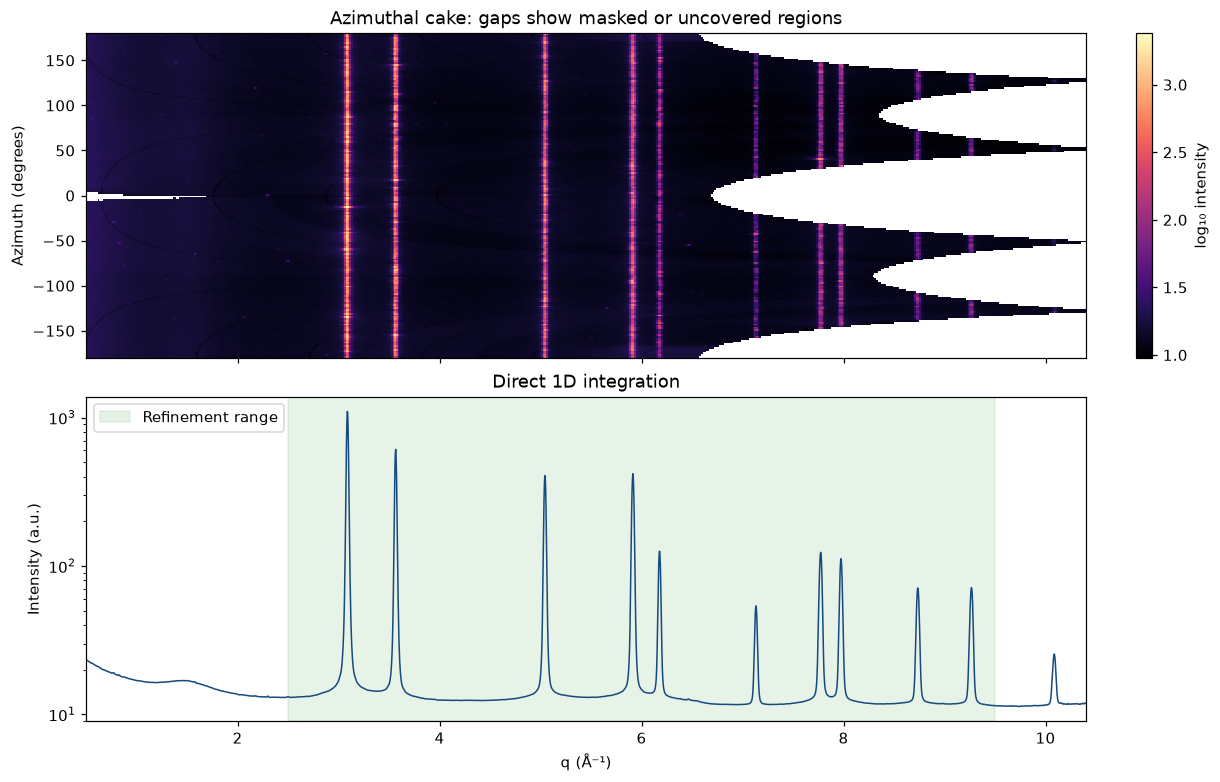

In [3]:
Q_RANGE = [0.5, 10.4]
DELTA_Q = 0.004
FIT_RANGE = [2.5, 9.5]
method = ('bbox', 'csr', 'cython')
full = exrd()
full.load_xrd_data(from_tiff_file=str(BASE / 'Ni.tiff'), ai=ai, mask=mask,
                   integrate2d=False, radial_range=Q_RANGE, delta_q=DELTA_Q,
                   method=method, ds_attrs={}, plot=False)
q = full.ds.i1d.radial.values.astype(float)
y = full.ds.i1d.values.astype(float)
tth = np.degrees(2 * np.arcsin(q * wavelength / (4 * np.pi)))
ai.empty = np.nan
az = ai.integrate1d(image, npt=len(q), radial_range=Q_RANGE, mask=mask,
                    unit='q_A^-1', method=method, error_model='azimuthal',
                    correctSolidAngle=True, polarization_factor=None)
assert np.allclose(q, az.radial, atol=1e-6)
assert np.allclose(y, az.intensity, rtol=1e-6)
assert np.all(np.isfinite(y)) and np.all(az.count > 0)
sigma_proxy = np.sqrt(np.maximum(y, 1.0))
profile = pd.DataFrame({'q_A^-1': q, 'two_theta_deg': tth, 'intensity_au': y,
                        'sigma_weight_proxy': sigma_proxy,
                        'sigma_azimuthal_diagnostic': az.sigma,
                        'effective_pixel_count': az.count})
profile.to_csv(OUT / 'Ni_integrated_profile.csv', index=False)
np.savetxt(OUT / 'Ni_2theta.xy', np.c_[tth, y], header='two_theta_deg intensity_au; wavelength_A=0.1799')
np.savetxt(OUT / 'Ni_q.xy', np.c_[q, y], header='q_A^-1 intensity_au')
np.savetxt(OUT / 'Ni_2theta.xye', np.c_[tth, y, sigma_proxy],
           header='two_theta_deg intensity_au sigma_weight_proxy; sigma is sqrt(max(I,1)), NOT a measured uncertainty')
print(f'Exported {len(q)} bins; q={q.min():.3f}–{q.max():.3f} Å⁻¹; 2θ={tth.min():.3f}–{tth.max():.3f}°')
cake = ai.integrate2d(image, npt_rad=600, npt_azim=180, radial_range=Q_RANGE,
                      mask=mask, unit='q_A^-1', method=method,
                      correctSolidAngle=True, polarization_factor=None)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
pc = axes[0].pcolormesh(cake.radial, cake.azimuthal,
                        np.ma.masked_invalid(np.log10(np.maximum(cake.intensity, 1))),
                        shading='auto', cmap='magma')
axes[0].set(ylabel='Azimuth (degrees)', title='Azimuthal cake: gaps show masked or uncovered regions')
fig.colorbar(pc, ax=axes[0], label='log₁₀ intensity')
axes[1].semilogy(q, y, lw=1, color='#174a7e')
axes[1].axvspan(*FIT_RANGE, alpha=0.09, color='green', label='Refinement range')
axes[1].set(xlabel='q (Å⁻¹)', ylabel='Intensity (a.u.)', title='Direct 1D integration')
axes[1].legend()
fig.savefig(OUT / 'Ni_integration.png', dpi=180)
plt.show()

## 3. Phase matching against the supplied CIF

The supplied structure is face-centered cubic Ni, space group **Fm-3m (No. 225)**. Predicted peak positions/intensities below are calculated from the supplied CIF before refinement. Peak matching supports Ni as the major crystalline phase; a single-phase model is not a quantitative purity or detection-limit measurement.

,hkl,q_CIF_A^-1,q_observed_bin_A^-1,delta_q_A^-1,two_theta_CIF_deg,relative_CIF_intensity
0,"(1, 1, 1)",3.08681,3.086,-0.00081,5.06554,100.00000
1,"(2, 0, 0)",3.56435,3.566,0.00166,5.84982,49.17456
2,"(2, 2, 0)",5.04075,5.042,0.00126,8.27649,32.23220
3,"(3, 1, 1)",5.91080,5.914,0.00320,9.70822,36.44297
4,"(2, 2, 2)",6.17363,6.178,0.00437,10.14101,10.30463
5,"(4, 0, 0)",7.12869,7.134,0.00531,11.71495,4.36242
6,"(3, 3, 1)",7.76831,7.774,0.00569,12.77026,12.21386
7,"(4, 2, 0)",7.97012,7.974,0.00388,13.10345,10.97284
8,"(4, 2, 2)",8.73083,8.734,0.00317,14.36040,7.53216
9,"(5, 1, 1) / (3, 3, 3)",9.26044,9.266,0.00556,15.23653,7.95078


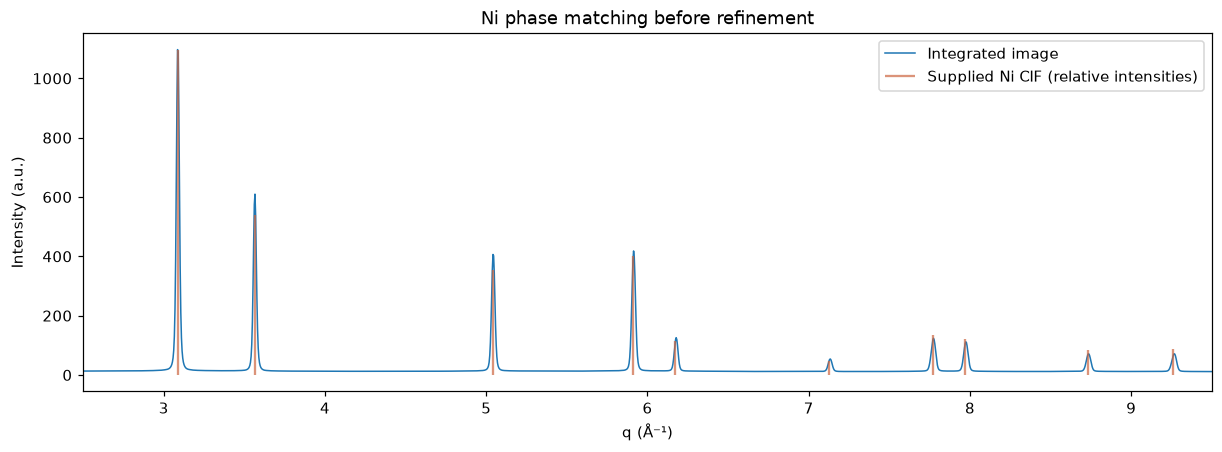

In [4]:
fit_sel = (q >= FIT_RANGE[0]) & (q <= FIT_RANGE[1])
sample = exrd()
sample.load_xrd_data(from_da_i1d=full.ds.i1d.sel(radial=slice(*FIT_RANGE)), plot=False)
sample.load_phases([{'cif': str(BASE / 'Ni.cif'), 'label': 'Ni'}], plot=False)
structure = Structure.from_file(BASE / 'Ni.cif')
predicted = XRDCalculator(wavelength=wavelength).get_pattern(structure, two_theta_range=(float(tth[fit_sel].min()), float(tth[fit_sel].max())))
pred_q = 4*np.pi*np.sin(np.radians(predicted.x)/2)/wavelength
peaks, _ = find_peaks(y, prominence=10, distance=20)
rows = []
for qp, tt, intensity, hkls in zip(pred_q, predicted.x, predicted.y, predicted.hkls):
    j = peaks[np.argmin(abs(q[peaks] - qp))]
    rows.append({'hkl': ' / '.join(str(h['hkl']) for h in hkls), 'q_CIF_A^-1': qp,
                 'q_observed_bin_A^-1': q[j], 'delta_q_A^-1': q[j]-qp,
                 'two_theta_CIF_deg': tt, 'relative_CIF_intensity': intensity})
phase_matches = pd.DataFrame(rows)
phase_matches.to_csv(OUT / 'Ni_phase_matches.csv', index=False)
display(phase_matches.round(5))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(q, y, lw=1, label='Integrated image')
ax.vlines(pred_q, 0, predicted.y / 100 * y.max(), color='#cc6540', alpha=.7, label='Supplied Ni CIF (relative intensities)')
ax.set(xlim=FIT_RANGE, xlabel='q (Å⁻¹)', ylabel='Intensity (a.u.)', title='Ni phase matching before refinement')
ax.legend()
fig.savefig(OUT / 'Ni_phase_matching.png', dpi=180)
plt.show()

## 4. Initialize a true Rietveld model from the reference instrument

Refined parameters: histogram scale, eight Chebyshev background coefficients, the cubic lattice parameter, then Gaussian U/V/W and Lorentzian X/Y profile terms. **Wavelength, zero offset, polarization, Z, and SH/L remain fixed** to the reference values. Site position and occupancy are fixed to the symmetry-constrained, fully occupied Ni site.

GSAS-II defaults include nonzero size/strain broadening. We explicitly set the size to 10 μm (effectively a narrow reference contribution) and microstrain to zero and keep both fixed, allowing the profile coefficients to describe total broadening. Thus this refinement does **not** independently measure crystallite size or strain, and its fitted profile coefficients must not be presented as a new instrumental calibration.

A fixed-reference-profile checkpoint is saved for comparison. After profile refinement, an unconstrained Uiso trial checks whether the displacement parameter is supported. If it is negative, it is fixed at the physical lower boundary zero and the other parameters are refitted; a zero boundary result is not a measured thermal displacement.

In [5]:
sample.setup_gsas2_refiner(instprm_from_gpx=str(BASE / '_instrument_parameters.gpx'),
                           normalize=False, do_1st_refinement=False, plot=False)
sample.set_LeBail(to=False, refine=False, plot=False)
hist = sample.gpx.histograms()[0]
phase = sample.gpx.phases()[0]
assert phase.data['General']['SGData']['SpGrp'].replace(' ', '') == 'Fm-3m'
assert len(phase.data['Atoms']) == 1
for key, entry in reference_inst.items():
    if isinstance(entry[1], (int, float, np.number)):
        assert np.isclose(hist.data['Instrument Parameters'][0][key][1], entry[1])
hist.data['data'][1][2] = 1.0 / np.maximum(sample.ds.i1d.values.astype(float), 1.0)
hap = phase.data['Histograms'][hist.name]
hap['Size'][1][0] = 10.0
hap['Mustrain'][1][0] = 0.0
phase.data['Atoms'][0][10] = 0.0
phase.atom(phase.data['Atoms'][0][0]).refinement_flags = ''
assert hap['LeBail'] is False
history = []
def record(stage):
    r = sample.gpx['Covariance']['data']['Rvals']
    p = sample.gpx.phases()[0]
    history.append({'stage': stage, 'Rwp_percent': float(r['Rwp']), 'GOF_proxy': float(r['GOF']),
                    'a_A': float(p.get_cell()['length_a']), 'Uiso_A2': float(p.data['Atoms'][0][10]),
                    'n_parameters': int(r['Nvars']), 'max_shift_over_esd': float(r.get('Max shft/sig', np.nan))})
    print(stage, ': Rwp =', round(float(r['Rwp']), 4), '%')

In [6]:
sample.refine_background(num_coeffs=8, set_to_false_after_refinement=False, plot=False)
record('Scale + background; reference profile')
sample.refine_cell_parameters(set_to_false_after_refinement=False, plot=False)
record('Add lattice; reference profile')
sample.export_gpx_to(str(OUT / 'Ni_fixed_reference_profile.gpx'))
sample.refine_instrument_parameters(inst_pars_to_refine=['U', 'V', 'W'],
                                     set_to_false_after_refinement=False, plot=False)
record('Add Gaussian profile U,V,W')
sample.refine_instrument_parameters(inst_pars_to_refine=['X', 'Y'],
                                     set_to_false_after_refinement=False, plot=False)
record('Add Lorentzian profile X,Y')
sample.refine_site_property(site_ind=0, refinement_flags='U',
                            set_to_false_after_refinement=False, plot=False)
trial_Uiso = float(sample.gpx.phases()[0].data['Atoms'][0][10])
record('Diagnostic unconstrained Uiso trial')
sample.export_gpx_to(str(OUT / 'Ni_diagnostic_Uiso_trial.gpx'))
if trial_Uiso < 0:
    sample.gpx.phases()[0].data['Atoms'][0][10] = 0.0
    sample.clear_site_property_refinement(site_ind=0)
    print(f'Trial Uiso={trial_Uiso:.6g} Å² is negative; fix Uiso=0 and refit.')
else:
    print(f'Trial Uiso={trial_Uiso:.6g} Å² is nonnegative and retained.')
print(sample.refine())
record('Joint physical model')
# Final analytic-Jacobian least squares polishing handles strongly correlated profile terms.
# GSAS-II does not populate a Boolean converged field for this solver; stability is checked below.
sample.gpx.data['Controls']['data']['deriv type'] = 'analytic Jacobian'
sample.gpx.data['Controls']['data']['min dM/M'] = 1e-6
print(sample.refine())
record('Final analytic-Jacobian polish')
previous_a = sample.gpx.phases()[0].get_cell()['length_a']
previous_rwp = sample.gpx['Covariance']['data']['Rvals']['Rwp']
print(sample.refine())
record('Repeat-cycle stability check')
history_df = pd.DataFrame(history)
history_df.to_csv(OUT / 'Ni_refinement_history.csv', index=False)
display(history_df)

 ✅--Background with 8 coeffs is refined. Rwp/GoF is 26.698/1.326
Scale + background; reference profile : Rwp = 26.6979 %


 ✅--Cell parameters are refined. Rwp/GoF is now 22.220/1.104 (was 26.698(-16.77%)/1.326(-16.75%✨))
Add lattice; reference profile : Rwp = 22.2203 %


 ✅--Instrument parameter ['U', 'V', 'W'] is refined. Rwp/GoF is now 9.868/0.491 (was 22.220(-55.59%)/1.104(-55.55%✨))
Add Gaussian profile U,V,W : Rwp = 9.868 %


 ✅--Instrument parameter ['X', 'Y'] is refined. Rwp/GoF is now 7.297/0.363 (was 9.868(-26.06%)/0.491(-26.01%✨))
Add Lorentzian profile X,Y : Rwp = 7.2968 %


 ✅--U property of Ni0 site of Ni phase is refined. Rwp/GoF is now 6.016/0.299 (was 7.297(-17.56%)/0.363(-17.53%✨))
Diagnostic unconstrained Uiso trial : Rwp = 6.0157 %
Trial Uiso=-0.00134651 Å² is negative; fix Uiso=0 and refit.


Rwp/GoF is now 6.228/0.310 (was 6.016(3.52%)/0.299(3.49%❗))
Joint physical model : Rwp = 6.2276 %


Rwp/GoF is now 6.222/0.310 (was 6.228(-0.09%)/0.310(-0.09%❗))
Final analytic-Jacobian polish : Rwp = 6.222 %
Rwp/GoF is now 6.222/0.310 (was 6.222(0.00%)/0.310(0.00%❗))
Repeat-cycle stability check : Rwp = 6.222 %


,stage,Rwp_percent,GOF_proxy,a_A,Uiso_A2,n_parameters,max_shift_over_esd
0,Scale + background; reference profile,26.697919,1.326158,3.525576,0.000000,9,11.794556
1,Add lattice; reference profile,22.220311,1.104060,3.523282,0.000000,10,24.980060
2,"Add Gaussian profile U,V,W",9.868024,0.490736,3.523283,0.000000,13,32.002770
3,"Add Lorentzian profile X,Y",7.296842,0.363080,3.522689,0.000000,15,23.804502
4,Diagnostic unconstrained Uiso trial,6.015715,0.299419,3.522682,-0.001347,16,5.756779
5,Joint physical model,6.227557,0.309874,3.522678,0.000000,15,10.924078
6,Final analytic-Jacobian polish,6.222027,0.309599,3.522678,0.000000,15,0.398990
7,Repeat-cycle stability check,6.222027,0.309599,3.522678,0.000000,15,0.000000


## 5. Validate the saved model and quantify remaining limitations

The code checks that the final fit is Rietveld, its arrays and covariance are finite, the weights and manually recomputed Rwp agree with GSAS-II, the last refinement cycle is stable, and the Gaussian and Lorentzian width functions remain positive throughout the fit range. The correlation matrix is inspected explicitly because U/V/W can be highly correlated over a narrow 2θ range.

Formal lattice errors describe this fit with this fixed calibration and these relative weights. They exclude uncertainty in detector geometry, wavelength, texture, polarization, and model inadequacy. The PONI identifies **Ni itself as the calibration standard**, so the refined lattice parameter is not an independent validation of the absolute length scale. Residual peak-shape and intensity mismatch should be considered alongside Rwp.

In [7]:
hist = sample.gpx.histograms()[0]
phase = sample.gpx.phases()[0]
cov = sample.gpx['Covariance']['data']
rvals = cov['Rvals']
cell, cell_esd = phase.get_cell_and_esd()
x_fit = hist.getdata('x')
y_obs = hist.getdata('yobs')
y_calc = hist.getdata('ycalc')
y_bkg = hist.getdata('background')
weights = hist.getdata('yweight')
q_fit = 4*np.pi*np.sin(np.radians(x_fit)/2)/wavelength
residual = y_obs-y_calc
rwp_check = 100*np.sqrt(np.sum(weights*residual**2)/np.sum(weights*y_obs**2))
rp = 100*np.sum(abs(residual))/np.sum(abs(y_obs))
assert phase.data['Histograms'][hist.name]['LeBail'] is False
assert np.all(np.isfinite(np.c_[x_fit, y_obs, y_calc, y_bkg, weights]))
assert np.all(weights > 0) and np.allclose(weights, 1/np.maximum(y_obs,1), rtol=1e-6)
# Match the persisted histogram's recomputed residual. The optimizer's cached Rwp
# can differ slightly after GSAS-II regenerates the final profile.
assert np.isclose(rwp_check, hist.data['data'][0]['wR'], rtol=1e-7)
assert abs(rwp_check - rvals['Rwp']) < 0.01
assert not rvals.get('Aborted', False)
assert np.all(np.isfinite(cov['covMatrix'])) and np.all(np.diag(cov['covMatrix']) > 0)
assert abs(cell['length_a']-previous_a) < 1e-5
assert abs(float(rvals['Rwp'])-previous_rwp) < 0.01
inst = hist.data['Instrument Parameters'][0]
th = np.radians(x_fit/2)
gaussian_variance = inst['U'][1]*np.tan(th)**2 + inst['V'][1]*np.tan(th) + inst['W'][1]
lorentzian_width = inst['X'][1]/np.cos(th) + inst['Y'][1]*np.tan(th) + inst['Z'][1]
assert np.all(gaussian_variance > 0) and np.all(lorentzian_width > 0)
std = np.sqrt(np.diag(cov['covMatrix']))
corr = cov['covMatrix']/np.outer(std,std)
correlations = []
for i in range(len(std)):
    for j in range(i):
        if abs(corr[i,j]) >= .9:
            correlations.append({'parameter_1': cov['varyList'][i], 'parameter_2': cov['varyList'][j], 'correlation': corr[i,j]})
correlation_df = pd.DataFrame(correlations, columns=['parameter_1','parameter_2','correlation'])
correlation_df.to_csv(OUT / 'Ni_high_correlations.csv', index=False)
display(correlation_df)
parameter_table = pd.DataFrame([{'parameter': k, 'reference': reference_inst[k][1],
                                'final': v[1], 'refined': v[2]} for k,v in inst.items()])
parameter_table.to_csv(OUT / 'Ni_instrument_profile_comparison.csv', index=False)
display(parameter_table)
print(f'Rwp={rwp_check:.4f}%; Rp={rp:.4f}%; GOF (proxy weights)={rvals["GOF"]:.4f}')
print(f'a=b=c={cell["length_a"]:.8f} ± {cell_esd["length_a"]:.8f} Å (formal fit error only)')
print(f'V={cell["volume"]:.6f} Å³; maximum final shift/esd={rvals.get("Max shft/sig")}')

,parameter_1,parameter_2,correlation
0,:0:V,:0:U,-0.958770
1,:0:W,:0:V,-0.971664
2,:0:Y,:0:X,-0.931268


,parameter,reference,final,refined
0,Type,PXC,PXC,False
1,Bank,1.0,1.0,False
2,Lam,0.1799,0.1799,False
3,Polariz.,0.0,0.0,False
4,Azimuth,0.0,0.0,False
5,Zero,0.0,0.0,False
6,U,-29.429568,431.493223,True
7,V,13.791336,-31.827261,True
8,W,0.870891,2.255562,True
9,X,0.07517,1.205033,True


Rwp=6.2231%; Rp=4.7958%; GOF (proxy weights)=0.3096
a=b=c=3.52267787 ± 0.00003165 Å (formal fit error only)
V=43.713823 Å³; maximum final shift/esd=0.0


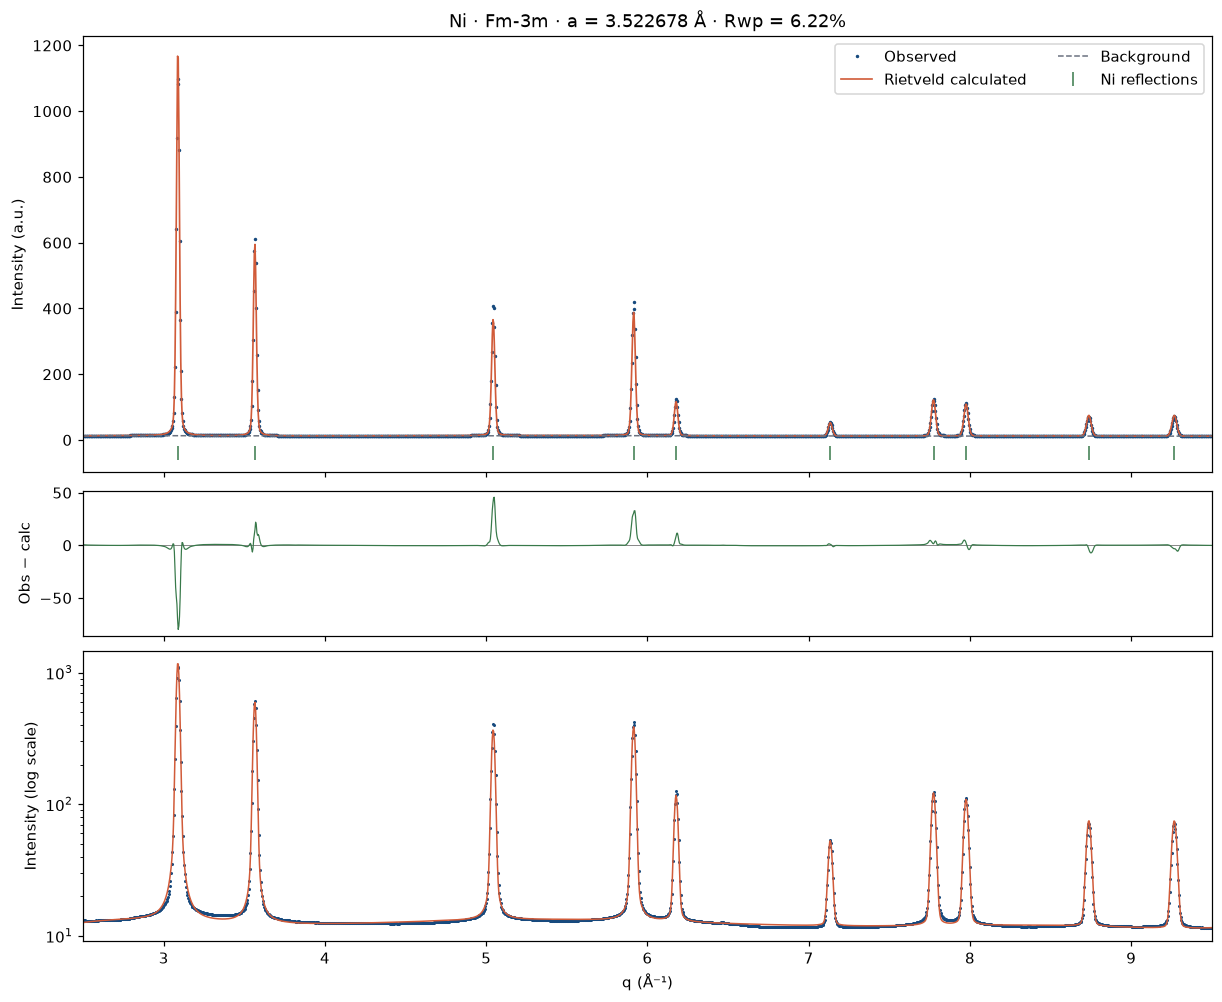

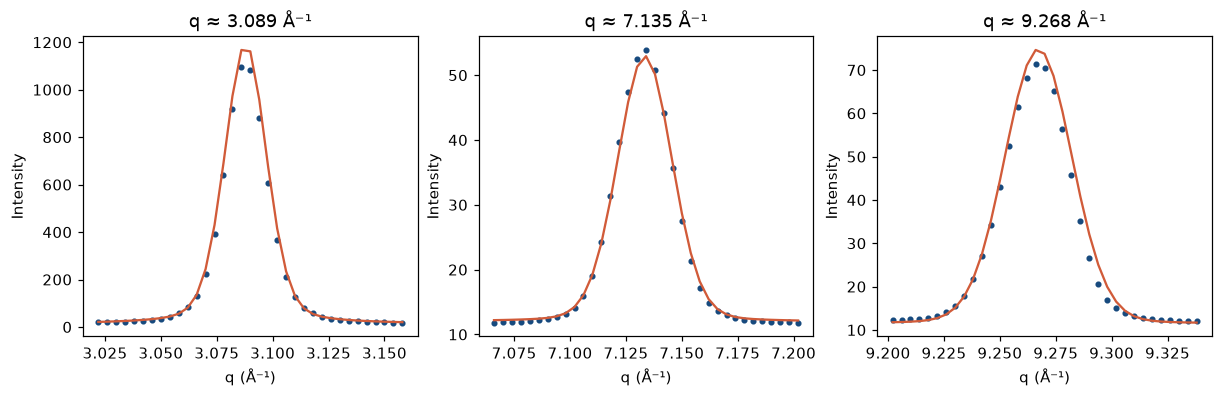

In [8]:
# Reflection positions are regenerated from the final structure for the tick marks.
refined_structure = Structure.from_str(sample.ds.attrs['PhaseInd_0_cif'], fmt='cif')
final_peaks = XRDCalculator(wavelength=wavelength).get_pattern(refined_structure,
    two_theta_range=(float(x_fit.min()), float(x_fit.max())))
ticks_q = 4*np.pi*np.sin(np.radians(final_peaks.x)/2)/wavelength
fig, (ax, diff, logax) = plt.subplots(3, 1, figsize=(11, 9), sharex=True,
                                    gridspec_kw={'height_ratios': [3,1,2]})
ax.plot(q_fit, y_obs, '.', ms=2.5, color='#174a7e', label='Observed')
ax.plot(q_fit, y_calc, '-', lw=1.1, color='#d15b39', label='Rietveld calculated')
ax.plot(q_fit, y_bkg, '--', lw=1, color='#6b7280', label='Background')
tick_y = -0.035 * y_obs.max()
ax.plot(ticks_q, np.full_like(ticks_q, tick_y), '|', ms=9, color='#38794a', label='Ni reflections')
ax.set(ylabel='Intensity (a.u.)', title=f'Ni · Fm-3m · a = {cell["length_a"]:.6f} Å · Rwp = {rwp_check:.2f}%')
ax.legend(ncol=2, loc='upper right')
diff.axhline(0, color='gray', lw=.6)
diff.plot(q_fit, residual, color='#38794a', lw=.8)
diff.set(ylabel='Obs − calc')
logax.semilogy(q_fit, y_obs, '.', ms=2, color='#174a7e')
logax.semilogy(q_fit, np.maximum(y_calc,1e-5), lw=1, color='#d15b39')
logax.set(xlabel='q (Å⁻¹)', ylabel='Intensity (log scale)', xlim=FIT_RANGE)
fig.savefig(OUT / 'Ni_Rietveld_fit.png', dpi=200)
fig.savefig(OUT / 'Ni_Rietveld_fit.pdf')
plt.show()
# Show representative peak shapes at low, intermediate, and high q.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, center in zip(axes, [ticks_q[0], ticks_q[len(ticks_q)//2], ticks_q[-1]]):
    sel = abs(q_fit-center) < .07
    ax.plot(q_fit[sel], y_obs[sel], 'o', ms=3, color='#174a7e')
    ax.plot(q_fit[sel], y_calc[sel], '-', color='#d15b39')
    ax.set(xlabel='q (Å⁻¹)', ylabel='Intensity', title=f'q ≈ {center:.3f} Å⁻¹')
fig.savefig(OUT / 'Ni_peak_details.png', dpi=180)
plt.show()

## 6. Save results and provenance

The primary result is `Ni_Rietveld.gpx`. `Ni_diagnostic_Uiso_trial.gpx` is explicitly an **unphysical diagnostic** if its displacement parameter is negative and must not be used as the accepted structural model. `Ni_fixed_reference_profile.gpx` is the comparison before fitting the total peak broadening.

`Ni_refined.cif` contains the final structure. `Ni_fit_profile.csv` contains the observed, calculated, background, difference, and fit-weight arrays. `Ni_summary.json` records the numerical result, weighting convention, and limitations. A full set of GSAS-II working files and logs is retained under `gsas_work/`.

In [9]:
sample.export_gpx_to(str(OUT / 'Ni_Rietveld.gpx'))
phase.export_CIF(outputname=str(OUT / 'Ni_refined.cif'))
pd.DataFrame({'q_A^-1': q_fit, 'two_theta_deg': x_fit, 'observed': y_obs,
              'calculated': y_calc, 'background': y_bkg, 'difference': residual,
              'weight_relative': weights}).to_csv(OUT / 'Ni_fit_profile.csv', index=False)
summary = {
    'phase': 'Ni', 'space_group': 'F m -3 m', 'method': 'Rietveld; LeBail=False',
    'wavelength_A': wavelength, 'fit_q_range_A^-1': FIT_RANGE, 'n_fit_points': len(x_fit),
    'a_A': float(cell['length_a']), 'a_formal_esd_A': float(cell_esd['length_a']),
    'volume_A3': float(cell['volume']), 'Rwp_percent': float(rwp_check), 'Rp_percent': float(rp),
    'optimizer_Rwp_percent': float(rvals['Rwp']), 'GOF_relative_weights': float(rvals['GOF']), 'n_refined_parameters': int(rvals['Nvars']),
    'Uiso_A2': float(phase.data['Atoms'][0][10]), 'unconstrained_trial_Uiso_A2': trial_Uiso,
    'final_max_shift_over_esd': float(rvals.get('Max shft/sig', np.nan)),
    'weighting': 'w=1/max(I,1); approximate relative intensity weights, not calibrated counting errors',
    'limitations': ['Uiso is at its zero boundary if the unconstrained trial is negative; not a thermal measurement.',
                    'Fitted profile coefficients include total broadening; size and strain are not independently determined.',
                    'Formal errors exclude calibration and other systematic uncertainties; PONI was calibrated with Ni.',
                    'Single-phase fit supports major-phase identification, not a quantitative purity claim.',
                    'Residual peak shape/intensity mismatch and strong profile-parameter correlations remain.'],
}
(OUT / 'Ni_summary.json').write_text(json.dumps(summary, indent=2))
provenance = {'inputs_sha256': input_hashes, 'versions': versions,
               'examples_repository': 'https://github.com/MehmetTopsakal/easyXRD_examples',
               'examples_commit': '97dec4ef8260006ebe8a00b78da2bbf55d9cd5ff',
               'integration': {'q_range': Q_RANGE, 'delta_q': DELTA_Q, 'method': method,
                                'solid_angle': True, 'polarization_factor': None, 'median_filter': None},
               'gsas_working_directory': str(Path(sample.gsasii_run_directory).relative_to(BASE))}
(OUT / 'Ni_provenance.json').write_text(json.dumps(provenance, indent=2))
# Verify persisted project/structure and confirm inputs have not changed.
reopened = G2sc.G2Project(gpxfile=str(OUT / 'Ni_Rietveld.gpx'))
assert reopened.phases()[0].data['Histograms'][reopened.histograms()[0].name]['LeBail'] is False
assert np.isclose(reopened.phases()[0].get_cell()['length_a'], cell['length_a'])
assert np.isclose(Structure.from_file(OUT / 'Ni_refined.cif').lattice.a, cell['length_a'], atol=1e-5)
assert input_hashes == {f: hashlib.sha256((BASE / f).read_bytes()).hexdigest() for f in required}
display(Markdown(f"""**Accepted result:** Ni, Fm-3m; **a = {cell['length_a']:.6f} Å**
(formal fit uncertainty {cell_esd['length_a']:.6f} Å), **Rwp = {rwp_check:.2f}%**.
The final model uses approximate relative weights and has **Uiso = {summary['Uiso_A2']:.5f} Å²**.
Residual mismatch and correlated profile terms remain; the fit does not independently establish
thermal displacement, crystallite size, microstrain, or absolute phase purity.

Saved notebook outputs and refinement files in **{OUT.name}/**."""))
print('\n'.join(str(p.relative_to(BASE)) for p in sorted(OUT.iterdir()) if p.is_file()))

**Accepted result:** Ni, Fm-3m; **a = 3.522678 Å**
(formal fit uncertainty 0.000032 Å), **Rwp = 6.22%**.
The final model uses approximate relative weights and has **Uiso = 0.00000 Å²**.
Residual mismatch and correlated profile terms remain; the fit does not independently establish
thermal displacement, crystallite size, microstrain, or absolute phase purity.

Saved notebook outputs and refinement files in **Ni_results/**.

Ni_results/Ni_2theta.xy
Ni_results/Ni_2theta.xye
Ni_results/Ni_Rietveld.gpx
Ni_results/Ni_Rietveld_fit.pdf
Ni_results/Ni_Rietveld_fit.png
Ni_results/Ni_detector_and_mask.png
Ni_results/Ni_diagnostic_Uiso_trial.gpx
Ni_results/Ni_fit_profile.csv
Ni_results/Ni_fixed_reference_profile.gpx
Ni_results/Ni_high_correlations.csv
Ni_results/Ni_instrument_profile_comparison.csv
Ni_results/Ni_integrated_profile.csv
Ni_results/Ni_integration.png
Ni_results/Ni_peak_details.png
Ni_results/Ni_phase_matches.csv
Ni_results/Ni_phase_matching.png
Ni_results/Ni_provenance.json
Ni_results/Ni_q.xy
Ni_results/Ni_refined.cif
Ni_results/Ni_refinement_history.csv
Ni_results/Ni_summary.json
